In [1]:
import os, sys
WORKDIR = "/home/choij/workspace/ChargedHiggsAnalysisV2/SignalRegionStudy"
sys.path.append(f"{WORKDIR}/python")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import pickle, joblib

import ROOT

Welcome to JupyROOT 6.30/04


In [22]:
ERA = "2017"
CHANNEL = "SR1E2Mu"
MASSPOINT = "MHc-100_MA-95"
NFOLD = 5

In [23]:
# Get fitting results
result = ROOT.TFile.Open(f"{WORKDIR}/templates/{ERA}/{CHANNEL}/{MASSPOINT}/Shape/Baseline/fit_result.root").Get("fitresult_model_data")
mA = result.floatParsFinal().find("mA").getVal()
sigma = result.floatParsFinal().find("sigma").getVal()
width = result.floatParsFinal().find("width").getVal()
print(mA, sigma, width)
window = 5*np.sqrt(sigma**2 + width**2)
print(window)

94.81928885756025 0.9231290147010198 0.9688866889954456
6.69124165214393


In [24]:
# Load datasetS
def load_dataset(process):
    events = {}
    for i in range(NFOLD):
        events[i] = []
    f = ROOT.TFile(f"{WORKDIR}/samples/{ERA}/{CHANNEL.replace('SR', 'Skim')}/{MASSPOINT}/{process}.root")
    tree = f.Get(f"{process}_Central")
    for idx, evt in enumerate(tree, start=1):
        condition = (mA-window) < evt.mass1 < (mA+window) or (mA-window) < evt.mass2 < (mA+window)
        if not condition:
            continue
        if evt.fold == -999:            
            print(process, evt.fold)
            continue
        events[evt.fold].append([evt.scoreX, evt.scoreY, evt.scoreZ, evt.weight, int(process == MASSPOINT)])
    return events

In [25]:
## training fold 0
## trainset = fold1, 2, 3, validset = fold 4, testset = fold 0
## First get all the events
events_sig = load_dataset(MASSPOINT)
events_bkg = {}
for i in range(NFOLD):
    events_bkg[i] = []

for bkg in ["WZ", "ZZ", "ttW", "ttZ", "ttH", "conversion", "nonprompt", "others"]:
    events_temp = load_dataset(bkg)
    for i in range(NFOLD):
        if events_bkg[i] is None:
            continue
        events_bkg[i].append(events_temp[i])
for i in range(NFOLD):
    events_sig[i] = np.array(events_sig[i])
    events_bkg[i] = np.concatenate(events_bkg[i], axis=0)   

In [26]:
def calculate_sensitivity(y_true, y_pred, weights, threshold):
    """
    Calculate S/sqrt(B) for a given threshold.
    """
    signal_mask = (y_true == 1) & (y_pred > threshold)
    background_mask = (y_true == 0) & (y_pred > threshold)

    S = np.sum(weights[signal_mask])
    B = np.sum(weights[background_mask])

    if B == 0:
        return 0  # Avoid division by zero

    return np.sqrt(2*((S+B)*np.log(1+S/B)-S))

def train_and_optimize_global_sensitivity(events_sig, events_bkg):
    """
    Train GradientBoostingClassifier on folds and find a single threshold
    that maximizes S/sqrt(B) across all folds.

    Parameters:
    - events_sig: Dictionary of signal events by fold.
                  Each value is a numpy array with columns [score_X, score_Y, score_Z, weight, class_label].
    - events_bkg: Dictionary of background events by fold.
                  Same structure as events_sig.

    Returns:
    - models: List of trained GradientBoostingClassifier models (one for each fold).
    - global_best_threshold: Threshold that maximizes S/sqrt(B) across all folds.
    - global_max_sensitivity: Maximum S/sqrt(B) achieved at the global threshold.
    """
    models = []

    # Collect validation predictions, weights, and labels across all folds
    all_val_preds = []
    all_val_weights = []
    all_val_labels = []

    for fold in range(NFOLD):
        # Prepare training and validation sets
        train_sig = [events_sig[f] for f in range(NFOLD) if f != fold]
        train_bkg = [events_bkg[f] for f in range(NFOLD) if f != fold]
        val_sig = events_sig[fold]
        val_bkg = events_bkg[fold]
        
        # Normalize background weights to match signal sum of weights
        sum_sig = np.sum([np.sum(data[:, 3]) for data in train_sig])
        sum_bkg = np.sum([np.sum(data[:, 3]) for data in train_bkg])
        
        train_bkg_norm = [data.copy() for data in train_bkg]
        for data in train_bkg_norm:
            data[:, 3] *= sum_sig / sum_bkg
        
        train_data = np.vstack(train_sig + train_bkg_norm)
        val_data = np.vstack([val_sig, val_bkg])

        X_train, w_train, y_train = train_data[:, :3], train_data[:, 3], train_data[:, 4]
        X_val, w_val, y_val = val_data[:, :3], val_data[:, 3], val_data[:, 4]

        # Train the classifier
        model = GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
        model.fit(X_train, y_train, sample_weight=w_train)

        # Get validation predictions
        y_val_pred = model.predict_proba(X_val)[:, 1]

        # Collect validation data
        all_val_preds.append(y_val_pred)
        all_val_weights.append(w_val)
        all_val_labels.append(y_val)

        models.append(model)

    # Merge all validation results
    all_val_preds = np.concatenate(all_val_preds)
    all_val_weights = np.concatenate(all_val_weights)
    all_val_labels = np.concatenate(all_val_labels)

    # Optimize global threshold for S/sqrt(B)
    thresholds = np.linspace(0, 1, 100)
    sensitivities = [calculate_sensitivity(all_val_labels, all_val_preds, all_val_weights, t) for t in thresholds]
    sensitivities[0]
    global_best_threshold = thresholds[np.argmax(sensitivities)]
    global_max_sensitivity = max(sensitivities)

    print(f"Global Best Threshold = {global_best_threshold:.3f}, Max S/sqrt(B) = {global_max_sensitivity:.4f}, improvement = {global_max_sensitivity/sensitivities[0]:.2f}")

    return models, global_best_threshold, global_max_sensitivity

# Example usage:
# Replace events_sig and events_bkg with actual data.
# Each should be a dictionary where keys are fold numbers (1 to 5) and values are numpy arrays with [score_X, score_Y, score_Z, weight, class_label].
models, global_best_threshold, global_max_sensitivity = train_and_optimize_global_sensitivity(events_sig, events_bkg)

Global Best Threshold = 0.374, Max S/sqrt(B) = 1.3911, improvement = 1.03


Warning in <TROOT::Append>: Replacing existing TH1: signal (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: background (Potential memory leak).


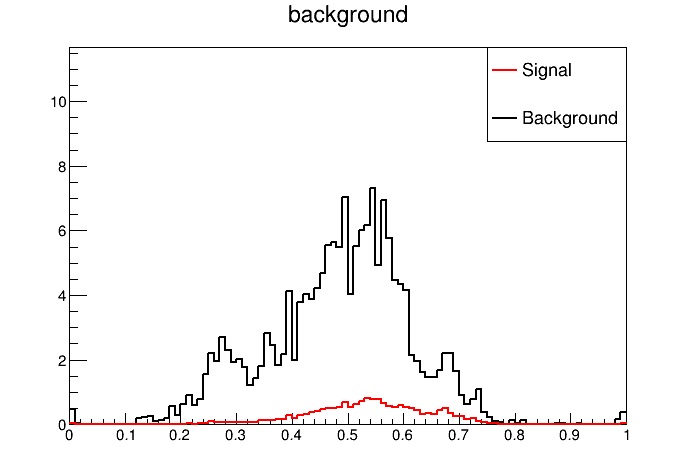

In [27]:
h_signal = ROOT.TH1F("signal", "signal", 100, 0, 1)
h_background = ROOT.TH1F("background", "background", 100, 0, 1)
for fold in range(NFOLD):
    model = models[fold]
    y_pred = model.predict_proba(events_sig[fold][:, :3])[:, 1]
    w_pred = events_sig[fold][:, 3]
    for score, weight in zip(y_pred, w_pred):
        h_signal.Fill(score, weight)
    
    y_pred = model.predict_proba(events_bkg[fold][:, :3])[:, 1]
    w_pred = events_bkg[fold][:, 3]
    for score, weight in zip(y_pred, w_pred):
        h_background.Fill(score, weight)
      
h_signal.SetStats(0)
h_signal.SetLineColor(ROOT.kRed)
h_signal.SetLineWidth(2)
h_background.SetStats(0)
h_background.SetLineColor(ROOT.kBlack)
h_background.SetLineWidth(2)
h_background.GetYaxis().SetRangeUser(0, h_background.GetMaximum()*1.6)

l = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)    
l.AddEntry(h_signal, "Signal", "l")
l.AddEntry(h_background, "Background", "l")

c = ROOT.TCanvas()
c.cd()
h_background.Draw("hist")
h_signal.Draw("histsame")
l.Draw()
c.Draw()